<a href="https://colab.research.google.com/github/Abhishek-563/Smart-Urban-Mobility-Analytics/blob/main/Smart_Urban_Mobility_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================
# Smart Urban Mobility Analytics
# Seoul Bike Sharing Demand Analysis
# ======================================

In [1]:
# Install packages (Google Colab)

!pip install pandas numpy matplotlib seaborn -q

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

sns.set(font_scale=1.1)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
import pandas as pd

# Load Dataset

# Unzip the dataset file
!unzip -o "/content/seoul+bike+sharing+demand.zip" -d "/content/"

df = pd.read_csv("/content/SeoulBikeData.csv", encoding='latin1')

df.head()

Archive:  /content/seoul+bike+sharing+demand.zip
 extracting: /content/SeoulBikeData.csv  


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
# Shape

print(df.shape)

(8760, 14)


In [7]:
# Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [8]:
# Statistical Summary

df.describe(include='all')

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,30/11/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,NaN,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,NaN,NaN,NaN
min,NaN,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN


In [9]:
# Missing Values

df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [10]:
# Duplicate Records

df.duplicated().sum()

np.int64(0)

In [11]:
# Remove duplicates

df = df.drop_duplicates()

print(df.shape)

(8760, 14)


In [12]:
# Rename Columns

df.columns = df.columns.str.strip()

df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

In [14]:
# Convert Date

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [15]:
# Check Datatypes

df.dtypes

,0
Date,datetime64[ns]
Rented Bike Count,int64
Hour,int64
Temperature(°C),float64
Humidity(%),int64
Wind speed (m/s),float64
Visibility (10m),int64
Dew point temperature(°C),float64
Solar Radiation (MJ/m2),float64
Rainfall(mm),float64


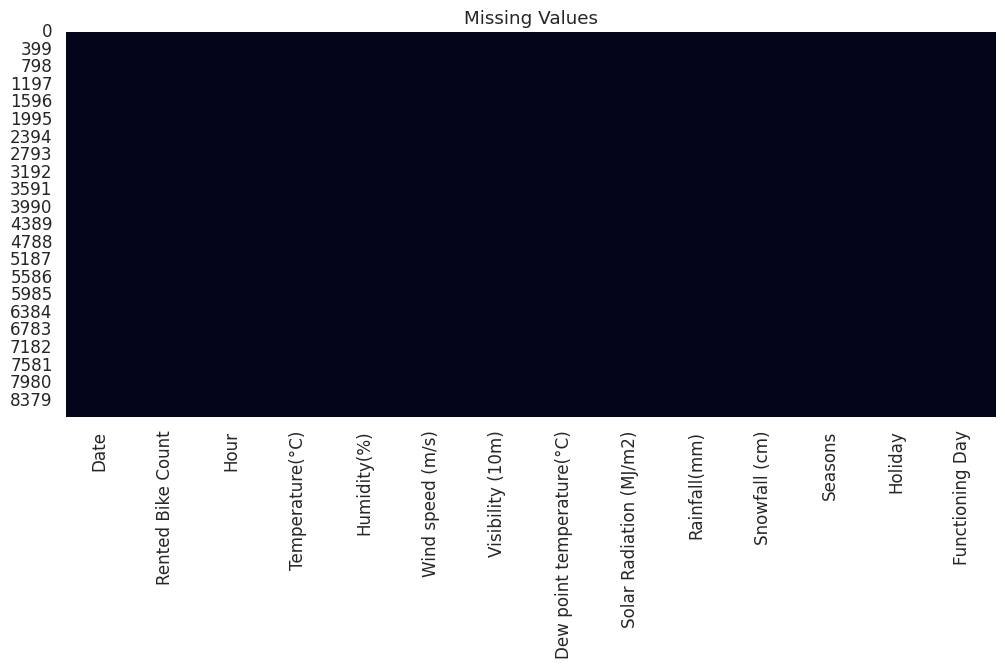

In [16]:
# Missing Values Heatmap

plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [17]:
# Outlier Detection

numeric = df.select_dtypes(include=np.number)

numeric.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)'],
      dtype='object')

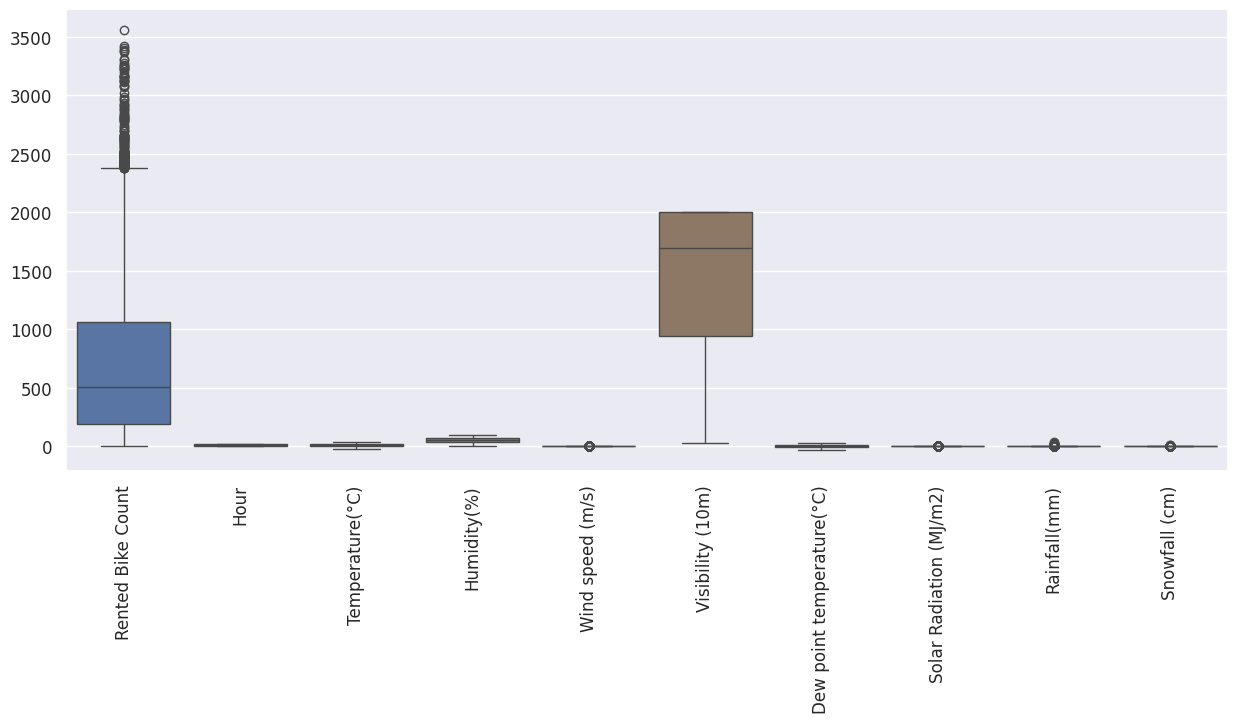

In [18]:
plt.figure(figsize=(15,6))

sns.boxplot(data=numeric)

plt.xticks(rotation=90)

plt.show()

In [19]:
# Year

df["Year"] = df["Date"].dt.year

In [20]:
# Month

df["Month"] = df["Date"].dt.month_name()

In [21]:
# Day Name

df["Day"] = df["Date"].dt.day_name()

In [22]:
# Weekend Flag

df["Weekend"] = np.where(df["Day"].isin(["Saturday","Sunday"]),
                         "Weekend",
                         "Weekday")

In [23]:
# Temperature Category

df["Temp_Category"] = pd.cut(
    df["Temperature(°C)"],
    bins=[-20,0,10,20,30,50],
    labels=["Very Cold","Cold","Pleasant","Warm","Hot"]
)

In [24]:
# Save Clean Dataset

df.to_csv("cleaned_data.csv", index=False)

Exploratory Data Analysis (EDA)

Basic Dataset Overview

In [25]:
print("="*50)
print("Dataset Shape:", df.shape)
print("="*50)

print("\nColumns:\n")
print(df.columns.tolist())

Dataset Shape: (8760, 19)

Columns:

['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day', 'Year', 'Month', 'Day', 'Weekend', 'Temp_Category']


In [26]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,8760,2018-05-31 23:59:59.999999744,2017-12-01 00:00:00,2018-03-02 00:00:00,2018-06-01 00:00:00,2018-08-31 00:00:00,2018-11-30 00:00:00,NaN
Rented Bike Count,8760.0,704.602055,0.0,191.0,504.5,1065.25,3556.0,644.997468
Hour,8760.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922582
Temperature(°C),8760.0,12.882922,-17.8,3.5,13.7,22.5,39.4,11.944825
Humidity(%),8760.0,58.226256,0.0,42.0,57.0,74.0,98.0,20.362413
Wind speed (m/s),8760.0,1.724909,0.0,0.9,1.5,2.3,7.4,1.0363
Visibility (10m),8760.0,1436.825799,27.0,940.0,1698.0,2000.0,2000.0,608.298712
Dew point temperature(°C),8760.0,4.073813,-30.6,-4.7,5.1,14.8,27.2,13.060369
Solar Radiation (MJ/m2),8760.0,0.569111,0.0,0.0,0.01,0.93,3.52,0.868746
Rainfall(mm),8760.0,0.148687,0.0,0.0,0.0,0.0,35.0,1.128193


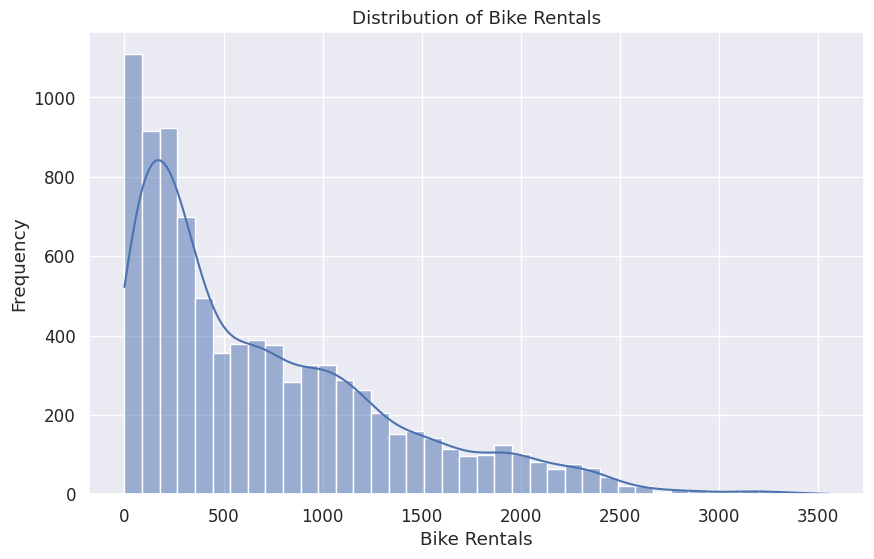

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(df["Rented Bike Count"], bins=40, kde=True)

plt.title("Distribution of Bike Rentals")
plt.xlabel("Bike Rentals")
plt.ylabel("Frequency")

plt.show()

Visualization 2: Average Rentals by Season

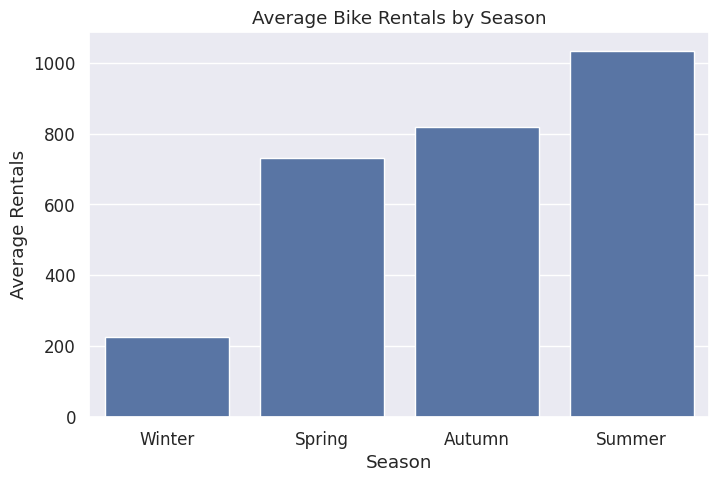

In [28]:
plt.figure(figsize=(8,5))

season = df.groupby("Seasons")["Rented Bike Count"].mean().sort_values()

sns.barplot(x=season.index,
            y=season.values)

plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")

plt.show()

Visualization 3: Rentals by Month

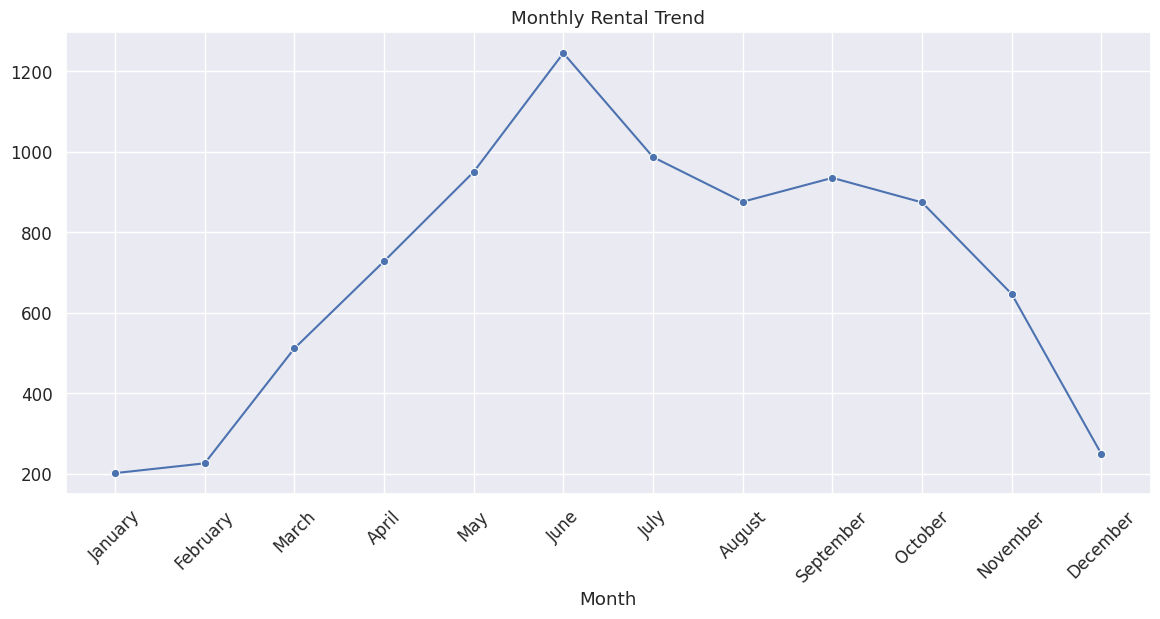

In [29]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(14,6))

monthly = df.groupby("Month")["Rented Bike Count"].mean().reindex(month_order)

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Rental Trend")

plt.show()

Visualization 4: Rentals by Hour

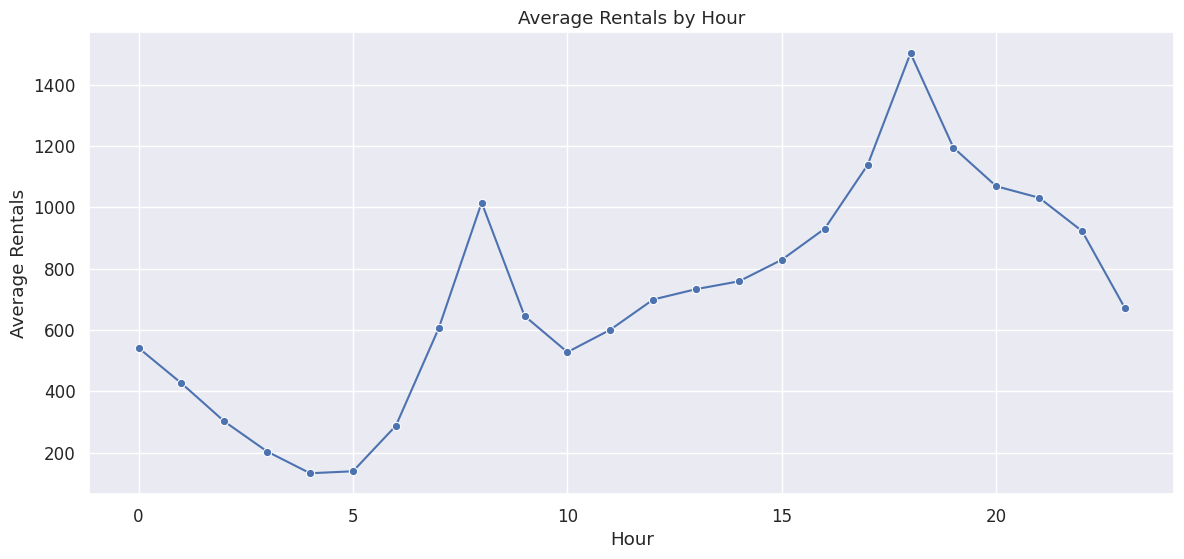

In [30]:
plt.figure(figsize=(14,6))

hourly = df.groupby("Hour")["Rented Bike Count"].mean()

sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker="o"
)

plt.title("Average Rentals by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Rentals")

plt.show()

Visualization 5: Rentals by Weekday

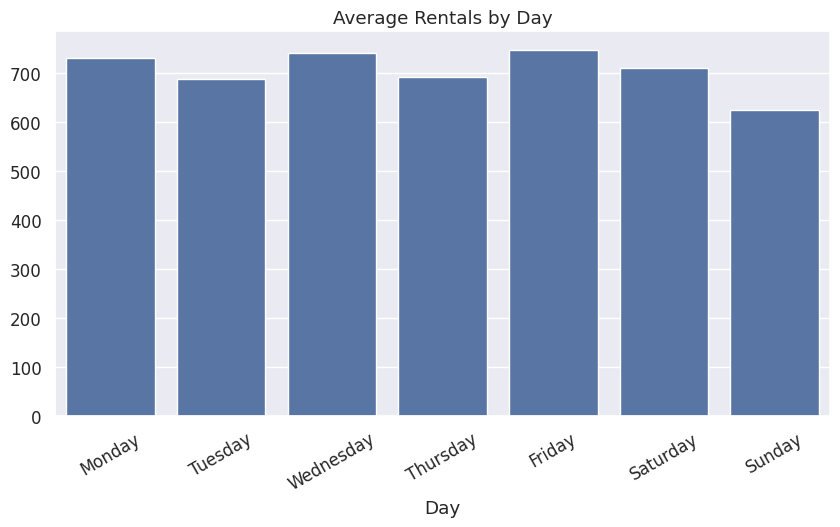

In [31]:
order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday",
    "Saturday","Sunday"
]

plt.figure(figsize=(10,5))

weekday = df.groupby("Day")["Rented Bike Count"].mean().reindex(order)

sns.barplot(
    x=weekday.index,
    y=weekday.values
)

plt.xticks(rotation=30)

plt.title("Average Rentals by Day")

plt.show()

Visualization 6: Weekend vs Weekday

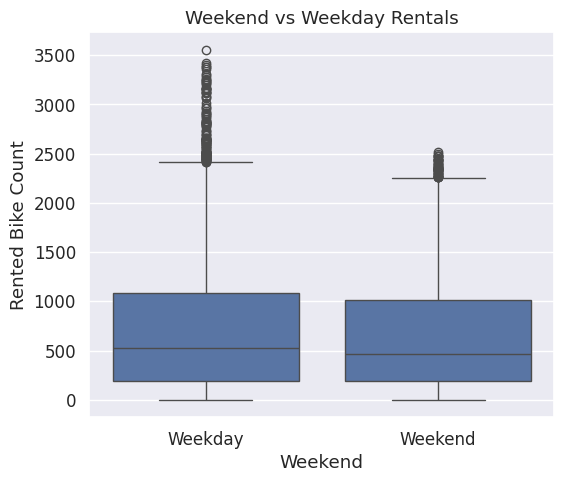

In [32]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="Weekend",
    y="Rented Bike Count",
    data=df
)

plt.title("Weekend vs Weekday Rentals")

plt.show()

Visualization 7: Temperature vs Rentals

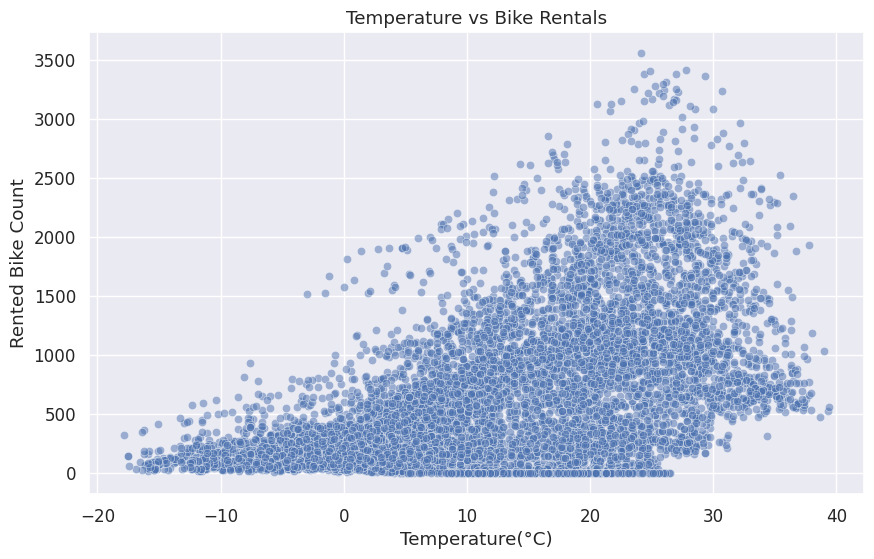

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Temperature(°C)",
    y="Rented Bike Count",
    data=df,
    alpha=0.5
)

plt.title("Temperature vs Bike Rentals")

plt.show()

Visualization 8: Humidity vs Rentals

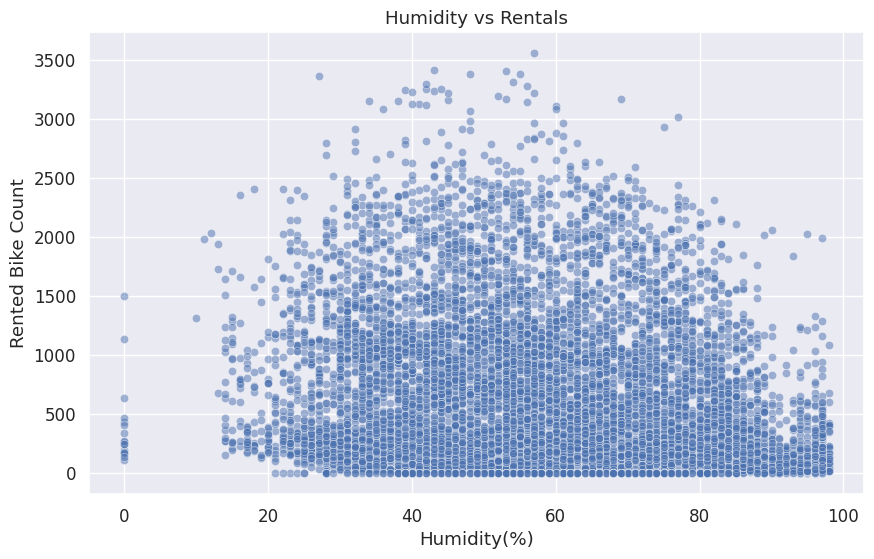

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Humidity(%)",
    y="Rented Bike Count",
    data=df,
    alpha=0.5
)

plt.title("Humidity vs Rentals")

plt.show()

Visualization 9: Rainfall Impact

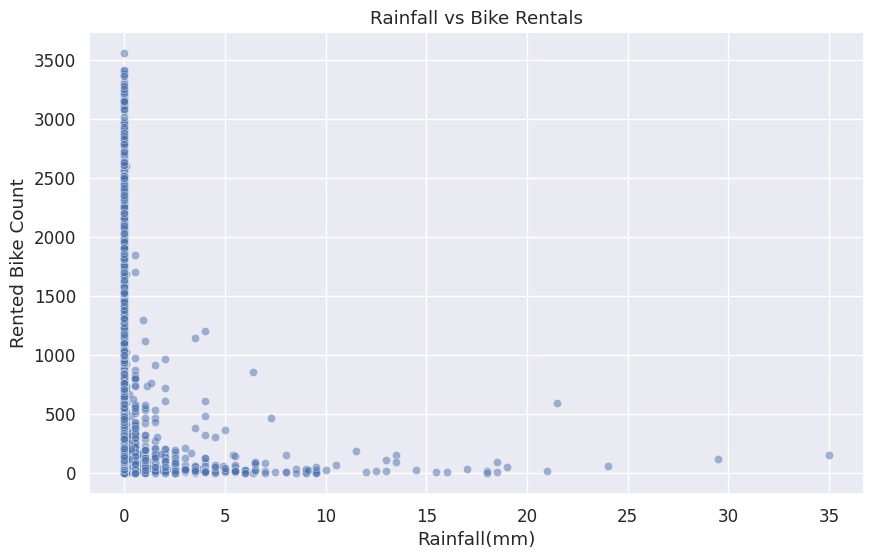

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Rainfall(mm)",
    y="Rented Bike Count",
    data=df,
    alpha=0.5
)

plt.title("Rainfall vs Bike Rentals")

plt.show()

Visualization 10: Snowfall Impact

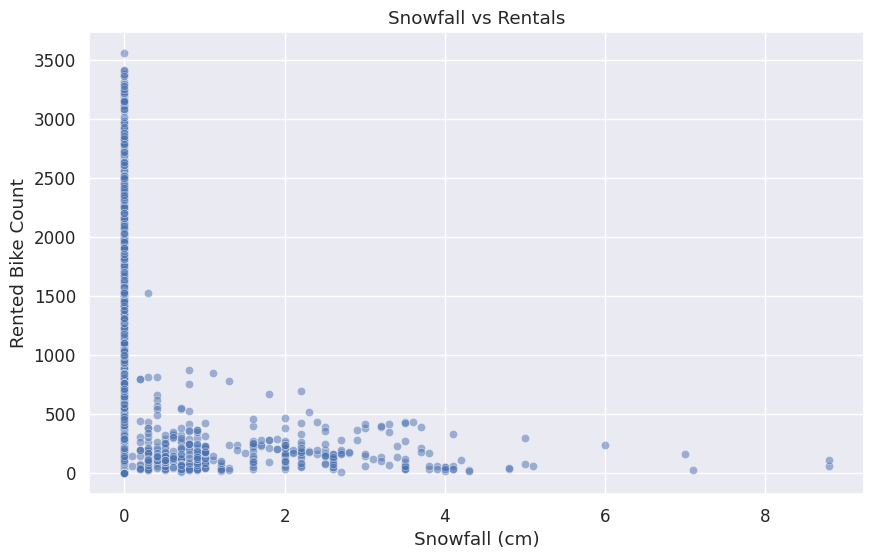

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Snowfall (cm)",
    y="Rented Bike Count",
    data=df,
    alpha=0.5
)

plt.title("Snowfall vs Rentals")

plt.show()

Visualization 11: Temperature Category Analysis

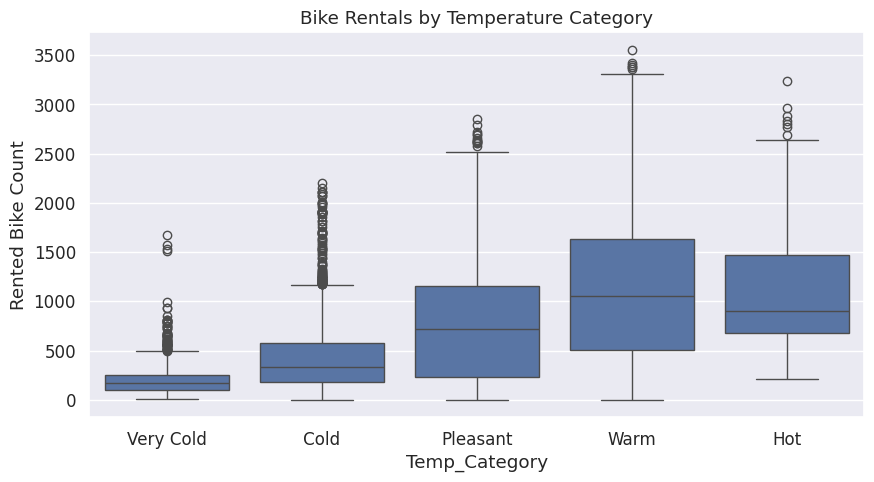

In [37]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Temp_Category",
    y="Rented Bike Count",
    data=df
)

plt.title("Bike Rentals by Temperature Category")

plt.show()

Visualization 12: Holiday Impact

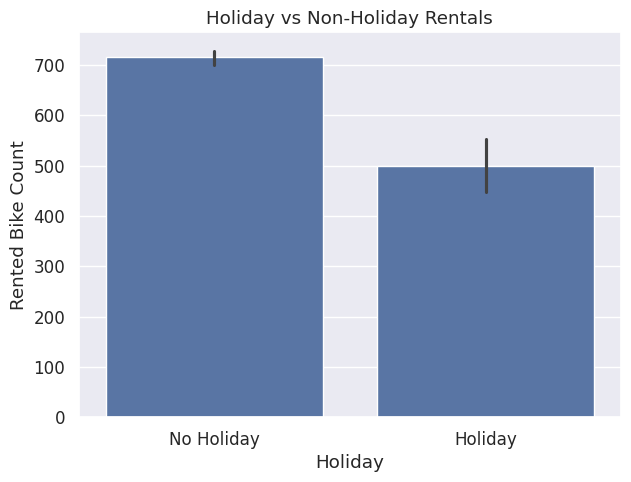

In [38]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Holiday",
    y="Rented Bike Count",
    data=df,
    estimator=np.mean
)

plt.title("Holiday vs Non-Holiday Rentals")

plt.show()

Visualization 13: Functioning Day Analysis

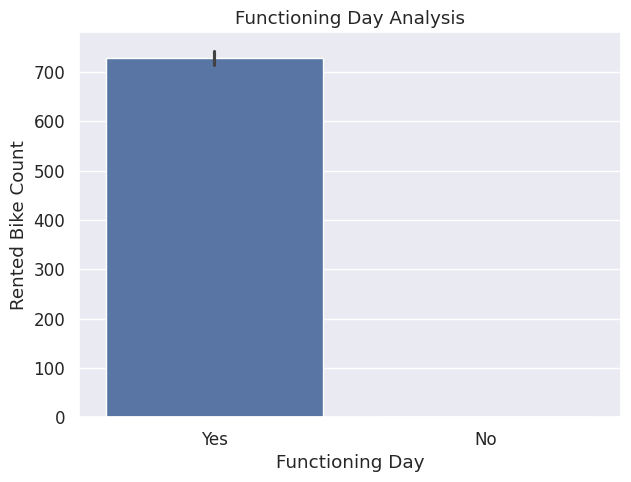

In [39]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Functioning Day",
    y="Rented Bike Count",
    data=df,
    estimator=np.mean
)

plt.title("Functioning Day Analysis")

plt.show()

Visualization 14: Correlation Heatmap

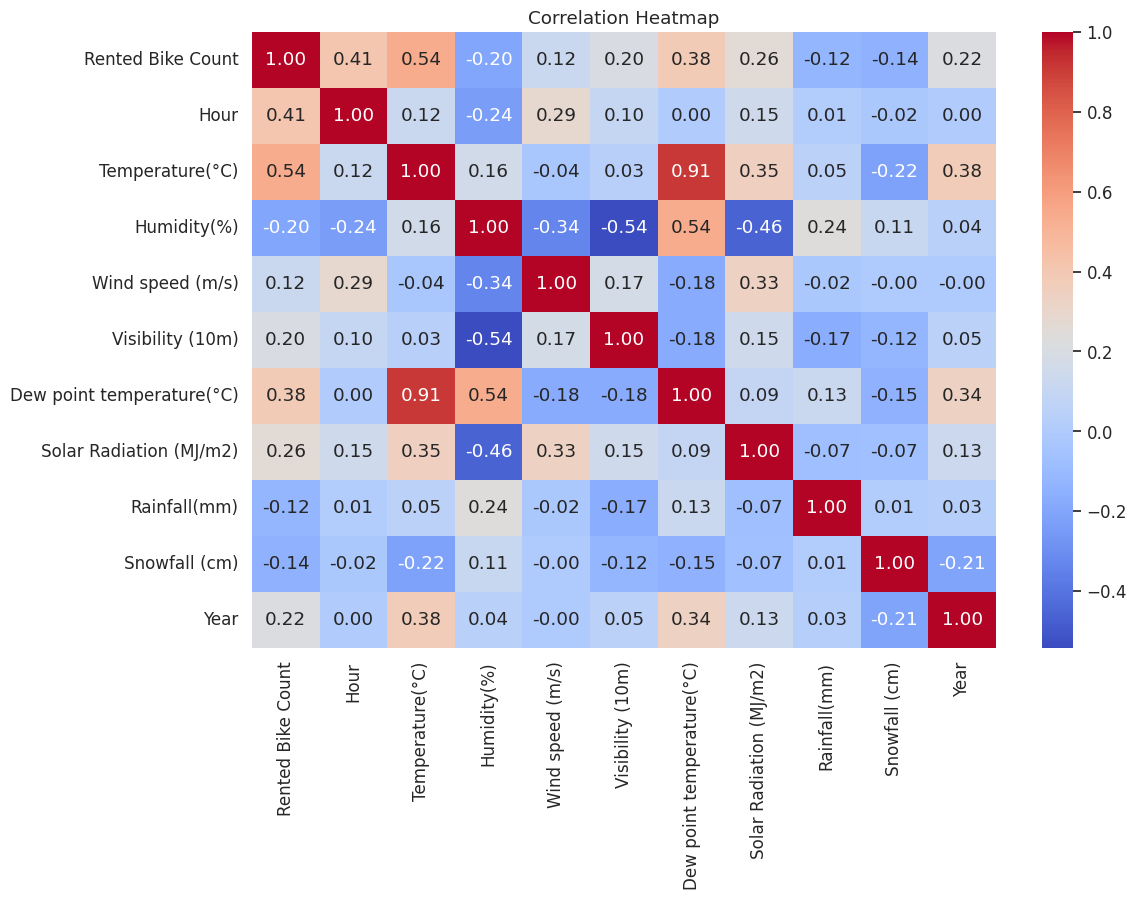

In [40]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Visualization 15: Pairplot (Selected Features)

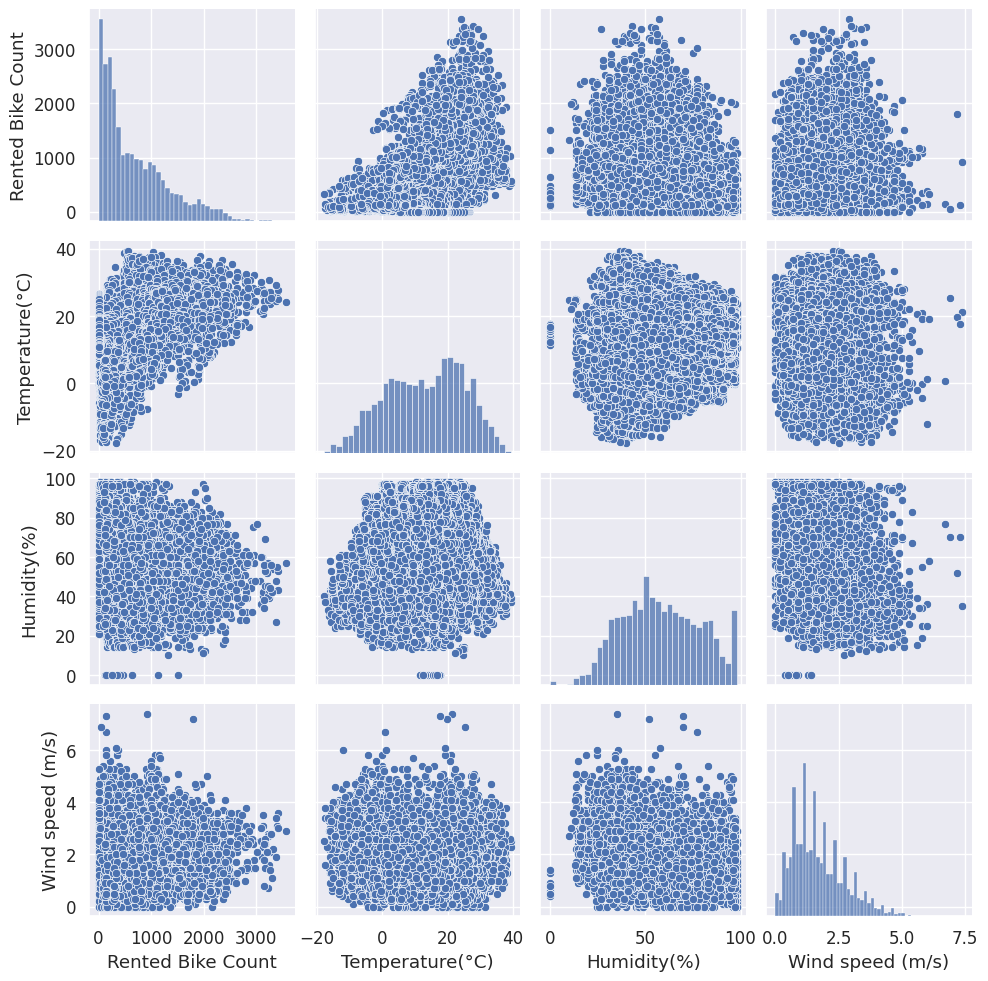

In [41]:
features = [
    "Rented Bike Count",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)"
]

sns.pairplot(df[features])

plt.show()

Save Visualizations

In [42]:
plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Monthly Rental Trend")

plt.tight_layout()

plt.savefig("monthly_trend.png")

plt.close()

Part 3 – KPI Analysis & Business Intelligence

Overall KPIs

In [43]:
# ==========================
# Overall Business KPIs
# ==========================

total_rentals = df["Rented Bike Count"].sum()

average_rentals = df["Rented Bike Count"].mean()

max_rentals = df["Rented Bike Count"].max()

min_rentals = df["Rented Bike Count"].min()

print("========== BUSINESS KPIs ==========")

print(f"Total Bike Rentals : {total_rentals:,}")

print(f"Average Rentals    : {average_rentals:.2f}")

print(f"Maximum Rentals    : {max_rentals}")

print(f"Minimum Rentals    : {min_rentals}")

========== BUSINESS KPIs ==========
Total Bike Rentals : 6,172,314
Average Rentals    : 704.60
Maximum Rentals    : 3556
Minimum Rentals    : 0


KPI 2 – Peak Rental Hour

In [44]:
hourly = df.groupby("Hour")["Rented Bike Count"].mean()

peak_hour = hourly.idxmax()

peak_value = hourly.max()

print("Peak Hour :", peak_hour)

print("Average Rentals :", round(peak_value,2))

Peak Hour : 18
Average Rentals : 1502.93


KPI 3 – Best Season

In [45]:
season = df.groupby("Seasons")["Rented Bike Count"].mean()

best = season.idxmax()

print("Best Performing Season :", best)

print(season)

Best Performing Season : Summer
Seasons
Autumn     819.597985
Spring     730.031250
Summer    1034.073370
Winter     225.541204
Name: Rented Bike Count, dtype: float64


KPI 4 – Best Month

In [46]:
monthly = df.groupby("Month")["Rented Bike Count"].mean()

print(monthly.sort_values(ascending=False))

Month
June         1245.676389
July          987.177419
May           950.387097
September     935.572222
August        876.192204
October       874.563172
April         728.093056
November      646.826389
March         511.551075
December      249.099462
February      225.941964
January       201.620968
Name: Rented Bike Count, dtype: float64


KPI 5 – Best Weekday

In [47]:
weekday = df.groupby("Day")["Rented Bike Count"].mean()

print(weekday.sort_values(ascending=False))

Day
Friday       747.117925
Wednesday    740.349359
Monday       730.563301
Saturday     709.528846
Thursday     690.704327
Tuesday      687.977564
Sunday       625.155449
Name: Rented Bike Count, dtype: float64


KPI 6 – Weekend vs Weekday

In [48]:
week = df.groupby("Weekend")["Rented Bike Count"].mean()

print(week)

Weekend
Weekday    719.448914
Weekend    667.342147
Name: Rented Bike Count, dtype: float64


KPI 7 – Holiday Analysis

In [49]:
holiday = df.groupby("Holiday")["Rented Bike Count"].mean()

holiday

,Rented Bike Count
Holiday,
Holiday,499.756944
No Holiday,715.228026


KPI 8 – Operating Day Performance

In [50]:
operation = df.groupby("Functioning Day")["Rented Bike Count"].mean()

operation

,Rented Bike Count
Functioning Day,
No,0.000000
Yes,729.156999


KPI 9 – Temperature Impact

In [ ]:
temp = df.groupby("Temp_Category")["Rented Bike Count"].mean()

temp



```KPI 10 – Top 10 Highest Rental Days
`# This is formatted as code`
```



In [51]:
top_days = df.groupby("Date")["Rented Bike Count"].sum()

top_days.sort_values(ascending=False).head(10)

,Rented Bike Count
Date,
2018-06-13,36149
2018-06-19,35349
2018-06-08,35103
2018-06-20,34639
2018-06-21,34621
2018-06-12,34544
2018-06-16,34360
2018-06-22,34079
2018-07-06,33676


KPI 11 – Lowest Rental Days

In [52]:
top_days.sort_values().head(10)

,Rented Bike Count
Date,
2018-09-28,0
2018-09-30,0
2018-10-04,0
2018-10-02,0
2018-09-19,0
2018-09-18,0
2018-11-09,0
2018-10-09,0
2018-04-11,0


KPI 12 – Rain Impact

In [53]:
rain = df.groupby(df["Rainfall(mm)"]>0)["Rented Bike Count"].mean()

rain

,Rented Bike Count
Rainfall(mm),
False,739.311103
True,163.456439


KPI 13 – Snow Impact

In [54]:
snow = df.groupby(df["Snowfall (cm)"]>0)["Rented Bike Count"].mean()

snow

,Rented Bike Count
Snowfall (cm),
False,732.272935
True,185.101580


KPI 14 – High Temperature Rentals

In [55]:
high_temp = df[df["Temperature(°C)"]>25]

high_temp["Rented Bike Count"].mean()

np.float64(1181.8262316910786)

KPI 15 – Rental Variability

In [56]:
std = df["Rented Bike Count"].std()

print("Standard Deviation :", round(std,2))

Standard Deviation : 645.0


Executive KPI Dashboard

In [57]:
summary = pd.DataFrame({

"KPI":[

"Total Rentals",

"Average Rentals",

"Maximum Rentals",

"Minimum Rentals",

"Peak Hour",

"Best Season"

],

"Value":[

total_rentals,

round(average_rentals,2),

max_rentals,

min_rentals,

peak_hour,

best

]

})

summary

,KPI,Value
0,Total Rentals,6172314
1,Average Rentals,704.6
2,Maximum Rentals,3556
3,Minimum Rentals,0
4,Peak Hour,18
5,Best Season,Summer


Export KPI Report

In [58]:
summary.to_csv("KPI_Report.csv",index=False)

Dashboard Summary (Matplotlib)

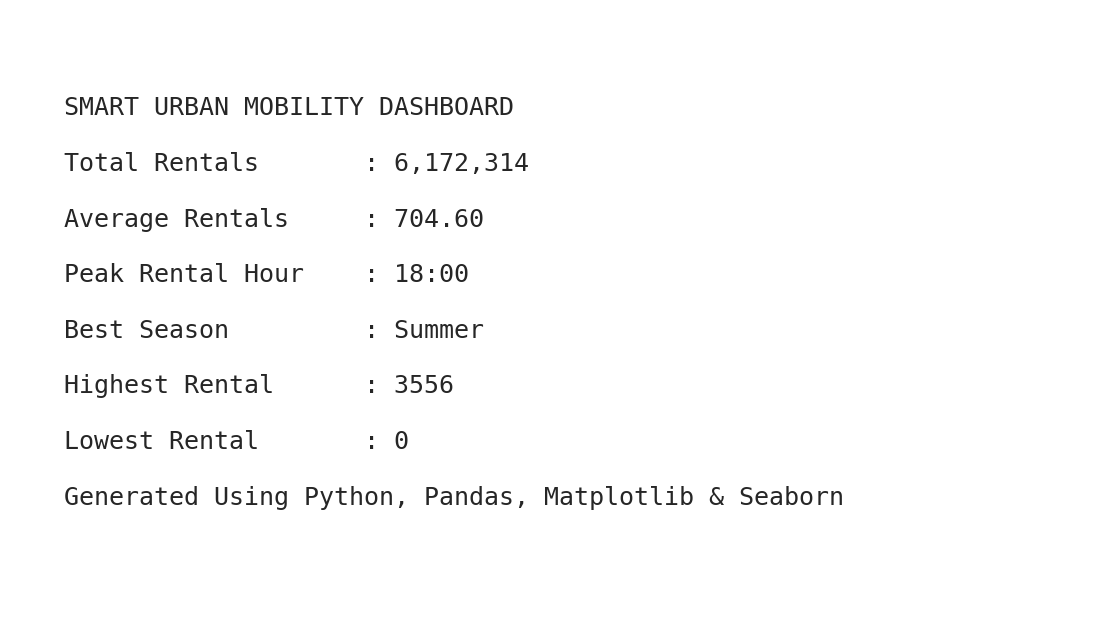

In [59]:
fig = plt.figure(figsize=(14,8))

plt.axis("off")

summary_text = f"""

SMART URBAN MOBILITY DASHBOARD

Total Rentals       : {total_rentals:,}

Average Rentals     : {average_rentals:.2f}

Peak Rental Hour    : {peak_hour}:00

Best Season         : {best}

Highest Rental      : {max_rentals}

Lowest Rental       : {min_rentals}

Generated Using Python, Pandas, Matplotlib & Seaborn

"""

plt.text(
    0.05,
    0.95,
    summary_text,
    fontsize=18,
    va="top",
    family="monospace"
)

plt.savefig("dashboard_summary.png", dpi=300, bbox_inches="tight")

plt.show()